## 1. Setup & Data Loading

In [285]:
import pandas as pd
import sqlite3
conn = sqlite3.connect(':memory:')
import numpy as np
df=pd.read_csv(r'C:\Users\SisonM\Downloads\Code\narrowresult (1).zip')
site_df=pd.read_csv(r'C:\Users\SisonM\Downloads\Code\station.zip')
df.to_sql('water_quality', conn, index=False, if_exists='replace')
query = "SELECT * FROM water_quality LIMIT 5;"
pd.read_sql_query(query,conn)


C:\Users\SisonM\AppData\Local\Temp\ipykernel_24872\31955827.py:5: DtypeWarning: Columns (0: StatisticalBaseCode, 1: ResultAnalyticalMethod/MethodIdentifier, 2: ResultAnalyticalMethod/MethodQualifierTypeName, 3: AnalysisStartDate, 4: AnalysisStartTime/Time, 5: AnalysisStartTime/TimeZoneCode, 6: AnalysisEndDate, 7: AnalysisEndTime/Time, 8: AnalysisEndTime/TimeZoneCode, 9: ResultLaboratoryCommentText) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'C:\Users\SisonM\Downloads\Code\narrowresult (1).zip')


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,MonitoringLocationIdentifier,ResultIdentifier,DataLoggerLine,ResultDetectionConditionText,MethodSpecificationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure/MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultParticleSizeBasisText,PrecisionValue,DataQuality/BiasValue,ConfidenceIntervalValue,UpperConfidenceLimitValue,LowerConfidenceLimitValue,ResultCommentText,USGSPCode,ResultDepthHeightMeasure/MeasureValue,ResultDepthHeightMeasure/MeasureUnitCode,ResultDepthAltitudeReferencePointText,ResultSamplingPointName,BiologicalIntentName,BiologicalIndividualIdentifier,SubjectTaxonomicName,UnidentifiedSpeciesIdentifier,SampleTissueAnatomyName,GroupSummaryCountWeight/MeasureValue,GroupSummaryCountWeight/MeasureUnitCode,CellFormName,CellShapeName,HabitName,VoltismName,TaxonomicPollutionTolerance,TaxonomicPollutionToleranceScaleText,TrophicLevelName,FunctionalFeedingGroupName,TaxonomicDetailsCitation/ResourceTitleName,TaxonomicDetailsCitation/ResourceCreatorName,TaxonomicDetailsCitation/ResourceSubjectText,TaxonomicDetailsCitation/ResourcePublisherName,TaxonomicDetailsCitation/ResourceDate,TaxonomicDetailsCitation/ResourceIdentifier,FrequencyClassInformationUrl,ResultAnalyticalMethod/MethodIdentifier,ResultAnalyticalMethod/MethodIdentifierContext,ResultAnalyticalMethod/MethodName,ResultAnalyticalMethod/MethodUrl,ResultAnalyticalMethod/MethodQualifierTypeName,MethodDescriptionText,LaboratoryName,AnalysisStartDate,AnalysisStartTime/Time,AnalysisStartTime/TimeZoneCode,AnalysisEndDate,AnalysisEndTime/Time,AnalysisEndTime/TimeZoneCode,ResultLaboratoryCommentCode,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,LaboratoryAccreditationIndicator,LaboratoryAccreditationAuthorityName,TaxonomistAccreditationIndicator,TaxonomistAccreditationAuthorityName,LabSamplePreparationUrl,ProviderName
0,USGS-OH,USGS Ohio Water Science Center,nwisoh.01.01100109,2011-06-21,10:30:00,EDT,USGS-403054084320500,NWIS-88887033,None,Not Detected,None,"Nitrogen, mixed forms (NH3), (NH4), organic, (...",Total,NaN,NaN,None,Accepted,None,Actual,None,None,None,None,None,None,None,None,None,NaN,600.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ALGOR,USGS,Computation by NWIS algorithm,None,None,"NWIS User's Manual, QW System, Section 3.6.7",NaN,NaN,None,None,None,None,None,None,NaN,None,None,None,None,None,None,NWIS
1,USGS-OH,USGS Ohio Water Science Center,nwisoh.01.01100109,2011-06-21,10:30:00,EDT,USGS-403054084320500,NWIS-88887034,None,NaN,None,Organic Nitrogen,Total,3.600,mg/l,None,Accepted,None,Actual,None,None,None,None,None,None,None,None,None,NaN,605.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ALGOR,USGS,Computation by NWIS algorithm,None,None,"NWIS User's Manual, QW System, Section 3.6.7",NaN,NaN,None,None,None,None,None,None,NaN,None,None,None,None,None,None,NWIS
2,USGS-OH,USGS Ohio Water Science Center,nwisoh.01.01100109,2011-06-21,10:30:00,EDT,USGS-403054084320500,NWIS-88887035,None,Not Detected,None,Organic Nitrogen,Dissolved,NaN,NaN,None,Accepted,None,Actual,None,None,None,None,None,None,None,None,None,NaN,607.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,ALGOR,USGS,Computation by NWIS algorithm,None,None,"NWIS User's Manual, QW System, Section 3.6.7",NaN,NaN,None,None,None,None,None,None,NaN,None,None,None,None,None,None,NWIS
3,USGS-OH,USGS Ohio Water Science Center,nwisoh.01.01100109,2011-06-21,10:30:00,EDT,USGS-403054084320500,NWIS-88887036,None,NaN,None,Ammonia and ammonium,Dissolved,0.080,mg/l as N,None

## 2. Data Cleaning

In [286]:
columns= df.columns.tolist()
missing_values = df.isnull().sum().tolist()
missing_columns={'columns':columns,'missing_values':missing_values}
missing_df=pd.DataFrame(missing_columns)
missing_df.to_sql('missing_data', conn, index=False, if_exists='replace')
query = "SELECT * FROM missing_data WHERE missing_values == 36053;"
display(pd.read_sql_query(query,conn))
df= df.dropna(axis=1,how='all')
df.to_sql('water_quality', conn, index=False, if_exists='replace')
query = "SELECT * FROM water_quality LIMIT 5;"
pd.read_sql_query(query,conn)
print(len(df))

,columns,missing_values
0,DataLoggerLine,36053
1,ResultWeightBasisText,36053
2,ResultTimeBasisText,36053
3,ResultTemperatureBasisText,36053
4,ResultParticleSizeBasisText,36053
5,PrecisionValue,36053
6,DataQuality/BiasValue,36053
7,ConfidenceIntervalValue,36053
8,UpperConfidenceLimitValue,36053
9,LowerConfidenceLimitValue,36053


36053


In [287]:
print(f"\nNull count: {df['ResultMeasureValue'].isnull().sum()}")
print(f"Data type: {df['ResultMeasureValue'].dtype}")
print(f"\nUnique values (sample): {df['ResultMeasureValue'].unique()[:10]}")
print(len(df))


Null count: 13393
Data type: float64

Unique values (sample): [     nan 3.60e+00 8.00e-02 1.00e-03 3.70e+00 1.25e-01 3.10e-01 6.00e-02
 4.10e-02 9.30e-01]
36053


In [288]:
df['ResultMeasureValue'] = pd.to_numeric(df['ResultMeasureValue'], errors = 'coerce')
df = df.dropna(subset=['ResultMeasureValue'])
print(df['ResultMeasureValue'].isnull().sum())
print(df['CharacteristicName'].value_counts())
print(df['ResultMeasure/MeasureUnitCode'].value_counts())
df= df.dropna(axis=1,how='all')
pd.set_option('display.max_columns', None)
print(len(df))

0
CharacteristicName
Phosphorus                                                                     3166
Orthophosphate                                                                 3059
Kjeldahl nitrogen                                                              2415
Inorganic nitrogen (nitrate and nitrite) ***retired***use Nitrate + Nitrite    2362
Total Kjeldahl nitrogen (Organic N & NH3)                                      2115
Ammonia                                                                        2077
Total Phosphorus, mixed forms                                                  2068
Nitrate + Nitrite                                                              1882
Nitrite                                                                        1632
Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)                    460
Nitrate                                                                         421
Ammonia and ammonium                                   

In [289]:
df=df.dropna(subset=['AnalysisStartDate'])
df['AnalysisStartDate']=pd.to_datetime(df['AnalysisStartDate'])
df.set_index('AnalysisStartDate', inplace = True)
df = df.dropna(subset=['ResultMeasureValue'])
df.groupby(['AnalysisStartDate'])['ResultMeasureValue'].apply(list)
df = df.reset_index() # Convert AnalysisStartDate back to a column
df.to_sql('water_quality', conn, index=False,if_exists='replace')
query = 'SELECT AnalysisStartDate, ResultMeasureValue FROM water_quality ORDER BY AnalysisStartDate Limit 20;'
pd.read_sql_query(query,conn)

,AnalysisStartDate,ResultMeasureValue
0,2010-04-07 00:00:00,1.721
1,2010-04-07 00:00:00,0.263
2,2010-04-07 00:00:00,1.196
3,2010-04-07 00:00:00,11.400
4,2010-04-07 00:00:00,1.600
5,2010-04-07 00:00:00,11.400
6,2010-04-07 00:00:00,1.751
7,2010-04-07 00:00:00,11.427
8,2010-04-07 00:00:00,0.800
9,2010-04-07 00:00:00,0.776


In [290]:
def clean_phosphorus(df):
    subset = df[df['CharacteristicName'] == 'Phosphorus'].copy()
    subset['ResultMeasureValue'] = pd.to_numeric(subset['ResultMeasureValue'], errors='coerce')
    subset = subset.dropna(subset=['ResultMeasureValue'])
    
    # 'mg/l as P' -> ug/L as P
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/l as P', 'ResultMeasureValue'] *= 1000
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/l as P', 'ResultMeasure/MeasureUnitCode'] = 'ug/L as P'
    
    # 'mg/L' (unlabeled, assumed as P per note above) -> ug/L as P
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/L', 'ResultMeasureValue'] *= 1000
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/L', 'ResultMeasure/MeasureUnitCode'] = 'ug/L as P'
    
    # 'ug/L' already matches target unit — just relabel for clarity/consistency
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'ug/L', 'ResultMeasure/MeasureUnitCode'] = 'ug/L as P'
    
    return subset
site_df_unique = site_df.drop_duplicates(subset='MonitoringLocationIdentifier')
phosphorus_df = clean_phosphorus(df)
print("After cleaning:", len(phosphorus_df))
phosphorus_df = pd.merge(
    phosphorus_df,
    site_df_unique[['MonitoringLocationIdentifier', 'LatitudeMeasure', 'LongitudeMeasure']],
    on='MonitoringLocationIdentifier',
    how='left'
)
print("After merge:", len(phosphorus_df))
phosphorus_df=phosphorus_df.groupby(['ActivityStartDate', 'CharacteristicName', 'ResultMeasure/MeasureUnitCode',
    'MonitoringLocationIdentifier','LatitudeMeasure', 'LongitudeMeasure'])['ResultMeasureValue'].mean().reset_index()
print("After groupby:", len(phosphorus_df))


After cleaning: 659
After merge: 659
After groupby: 438


In [291]:
phosphorus_df['ActivityStartDate'] = pd.to_datetime(phosphorus_df['ActivityStartDate'])
phosphorus_df['Year'] = phosphorus_df['ActivityStartDate'].dt.year
phosphorus_df['Month'] = phosphorus_df['ActivityStartDate'].dt.month
print(phosphorus_df[['ActivityStartDate', 'Year', 'Month']].head())
print(phosphorus_df['MonitoringLocationIdentifier'].value_counts())

  ActivityStartDate  Year  Month
0        2010-04-28  2010      4
1        2010-04-28  2010      4
2        2010-04-28  2010      4
3        2010-04-29  2010      4
4        2010-05-13  2010      5
MonitoringLocationIdentifier
USGS-414111083223200    107
USGS-390111084080300     24
USGS-395520082281500     14
USGS-402001081095200     12
USGS-403042084324100     11
USGS-403054084320500     11
USGS-403111084273200     11
USGS-403139084293900     11
USGS-403200084320000     11
USGS-403210084273300     11
USGS-395431082310000     10
USGS-393023084022300     10
USGS-393039084005300     10
USGS-393118084000600     10
USGS-393217083593700     10
EPA_GLNPO-ER59            7
EPA_GLNPO-ER60            7
EPA_GLNPO-ER43            7
EPA_GLNPO-ER78M           7
USGS-393707083134100      7
USGS-412810082491000      6
USGS-413053082553000      6
USGS-414111083223201      6
USGS-401926081105100      6
USGS-403219081155500      6
USGS-395433081250100      6
USGS-400925081105700      6
ARMYCORPS-1CMB000

In [292]:
def orthophosphate(df):
    subset = df[df['CharacteristicName'] == 'Orthophosphate'].copy()
    subset['ResultMeasureValue'] = pd.to_numeric(subset['ResultMeasureValue'], errors='coerce')
    subset = subset.dropna(subset=['ResultMeasureValue'])
    
    # 'mg/l asPO4' -> ug/L as PO4
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/l asPO4', 'ResultMeasureValue'] *= 1000
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/l asPO4', 'ResultMeasure/MeasureUnitCode'] = 'ug/L as PO4' 
    # 'mg/L' (unlabeled, assumed as P per note above) -> ug/L as P
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/l as P', 'ResultMeasureValue'] *= 3066
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'mg/l as P', 'ResultMeasure/MeasureUnitCode'] = 'ug/L as PO4'
    
    # 'ug/L' already matches target unit — just relabel for clarity/consistency
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'ug/L', 'ResultMeasureValue'] *= 3.066
    subset.loc[subset['ResultMeasure/MeasureUnitCode'] == 'ug/L', 'ResultMeasure/MeasureUnitCode'] = 'ug/L as PO4'
    
    return subset
site_df_unique = site_df.drop_duplicates(subset='MonitoringLocationIdentifier')
orthophosphate_df = orthophosphate(df)
print("After cleaning:", len(orthophosphate_df))
orthophosphate_df = pd.merge(
    orthophosphate_df,
    site_df_unique[['MonitoringLocationIdentifier', 'LatitudeMeasure', 'LongitudeMeasure']],
    on='MonitoringLocationIdentifier',
    how='left'
)
print("After merge:", len(orthophosphate_df))
orthophosphate_df=orthophosphate_df.groupby(['ActivityStartDate', 'CharacteristicName', 'ResultMeasure/MeasureUnitCode',
    'MonitoringLocationIdentifier','LatitudeMeasure', 'LongitudeMeasure'])['ResultMeasureValue'].mean().reset_index()
print("After groupby:", len(orthophosphate_df))

After cleaning: 614
After merge: 614
After groupby: 217


In [293]:
orthophosphate_df.to_sql('orthophosphate_data', conn, index=False, if_exists='replace')
query = "SELECT * FROM orthophosphate_data LIMIT 30;"
pd.read_sql_query(query, conn)
query = "SELECT MonitoringLocationIdentifier, LatitudeMeasure, LongitudeMeasure, " \
"AVG(ResultMeasureValue) as avg_orthophosphate" \
" FROM orthophosphate_data GROUP BY MonitoringLocationIdentifier ORDER BY avg_orthophosphate DESC Limit 10;"
pd.read_sql_query(query, conn)


,MonitoringLocationIdentifier,LatitudeMeasure,LongitudeMeasure,avg_orthophosphate
0,USGS-390121084054100,39.022500,-84.094722,251.412000
1,USGS-402001081095200,40.333611,-81.164444,239.148000
2,USGS-390111084080300,39.019722,-84.134167,198.370200
3,USGS-403042084324100,40.511753,-84.544822,147.168000
4,USGS-403210084273300,40.536050,-84.459244,113.442000
5,USGS-414111083223200,41.686436,-83.375486,102.913472
6,USGS-403054084320500,40.515003,-84.534806,101.178000
7,USGS-414111083223201,41.686436,-83.375486,58.254000
8,USGS-393707083134100,39.618611,-83.228056,52.122000
9,USGS-412810082491000,41.469444,-82.819444,52.122000


## 3. SQL Exploration

In [294]:
query_yearly = "SELECT strftime('%Y', ActivityStartDate) AS Year, AVG(ResultMeasureValue) as avg_orthophosphate FROM orthophosphate_data GROUP BY Year ORDER BY Year LIMIT 20;"
pd.read_sql_query(query_yearly, conn)

,Year,avg_orthophosphate
0,2010,5.323172
1,2011,39.747110
2,2012,15.103823
3,2013,42.015931
4,2014,70.526855
5,2015,3.752667
6,2016,37.693404
7,2017,131.813472
8,2018,59.793500
9,2019,47.586596


In [295]:
query_monthly = "SELECT strftime('%m', ActivityStartDate) AS Month, AVG(ResultMeasureValue) as avg_orthophosphate FROM orthophosphate_data GROUP BY Month ORDER BY Month LIMIT 12;"
pd.read_sql_query(query_monthly, conn)

,Month,avg_orthophosphate
0,04,11.629697
1,05,159.432000
2,06,153.146700
3,07,131.667667
4,08,15.688802
5,09,58.254000
6,10,107.031273
7,11,75.117000


In [296]:
query = "SELECT MIN (ResultMeasureValue) as min_value, Max(ResultMeasureValue) as max_value, AVG(ResultMeasureValue) as avg_values FROM orthophosphate_data;"
pd.read_sql_query(query, conn)

,min_value,max_value,avg_values
0,0.814023,653.058,50.936879


In [297]:
total_water_quality_query = """
SELECT p.MonitoringLocationIdentifier
FROM water_quality p
INNER JOIN orthophosphate_data o
on p.MonitoringLocationIdentifier = o.MonitoringLocationIdentifier
GROUP BY p.MonitoringLocationIdentifier;"""
print(f"Stations with both Phosphorus and Orthophosphate data:{len(pd.read_sql_query(total_water_quality_query, conn))}")

Stations with both Phosphorus and Orthophosphate data:25


## 4. Machine Learning — Phosphorus

In [298]:
from sklearn.model_selection import train_test_split
X=phosphorus_df[['Year','Month']]
y=phosphorus_df[['ResultMeasureValue']]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(len(X_train), len(X_test))
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

350 88
Mean Squared Error: 6073.1373
R² Score: 0.2183


In [299]:
X = phosphorus_df[['LatitudeMeasure', 'LongitudeMeasure']]
y = phosphorus_df[['ResultMeasureValue']]
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))

350 88


In [300]:
model=LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}, R²: {r2:.4f}")

MSE: 6332.8403, R²: 0.1849


In [301]:
X = phosphorus_df[['Year', 'Month', 'LatitudeMeasure', 'LongitudeMeasure']]
y = phosphorus_df['ResultMeasureValue'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}")
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Random Forest - MSE: 2045.1423, R2: 0.7368
LongitudeMeasure    0.567142
Month               0.167226
LatitudeMeasure     0.134640
Year                0.130992
dtype: float64


In [302]:
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
def evaluate_model(df, features, target = 'ResultMeasureValue', label = ''):
    X = df[features]
    y = df[target]

    print(f"--- {label} ---")
    print(f"Rows: {len(df)}")

    rf_model = RandomForestRegressor(random_state=42)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
    print("Shuffled R² scores:", scores)
    print("Shuffled Mean R²:", scores.mean())

    param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
}
    grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='r2')
    grid_search.fit(X, y)
    print("Best parameters:", grid_search.best_params_)
    print("Best R2 score:", grid_search.best_score_)
    
    return grid_search
features = ['Year', 'Month', 'LatitudeMeasure', 'LongitudeMeasure']
phosphorus_results = evaluate_model(phosphorus_df, features, label='Phosphorus')

--- Phosphorus ---
Rows: 438
Shuffled R² scores: [0.71662845 0.79479531 0.46736428 0.65058158 0.65603222]
Shuffled Mean R²: 0.6570803685483243
Best parameters: {'max_depth': 10, 'n_estimators': 300}
Best R2 score: -0.5248819222940352


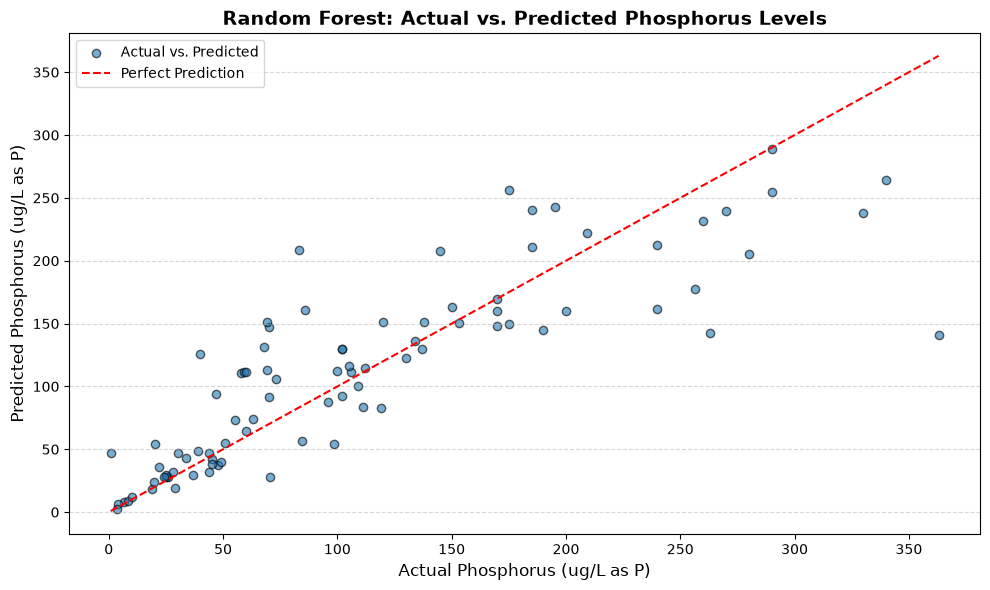

In [303]:
final_model = phosphorus_results.best_estimator_
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.6, edgecolor='black')
min_val = min(float(y_test.min()), float(y_pred_final.min()))
max_val = max(float(y_test.max()), float(y_pred_final.max()))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Phosphorus (ug/L as P)', fontsize=12)
plt.ylabel('Predicted Phosphorus (ug/L as P)', fontsize=12)
plt.title('Random Forest: Actual vs. Predicted Phosphorus Levels', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Actual vs. Predicted','Perfect Prediction'])
plt.tight_layout()
plt.show()

LongitudeMeasure    0.590402
Month               0.156809
LatitudeMeasure     0.128427
Year                0.124361
dtype: float64


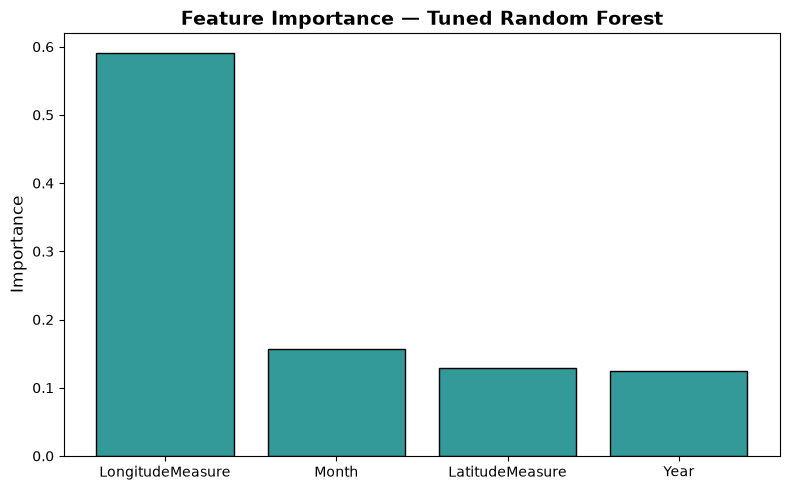

{'max_depth': 10, 'n_estimators': 300}


In [304]:
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
plt.figure(figsize=(8,5))
plt.bar(importances.index, importances.values, color=(0.2,0.6,0.6), edgecolor='black')
plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()
print(phosphorus_results.best_params_)

## 5. Machine Learning — Orthophosphate

In [305]:
orthophosphate_df['ActivityStartDate'] = pd.to_datetime(orthophosphate_df['ActivityStartDate'])
orthophosphate_df['Year'] = orthophosphate_df['ActivityStartDate'].dt.year
orthophosphate_df['Month'] = orthophosphate_df['ActivityStartDate'].dt.month
from sklearn.model_selection import train_test_split
X=orthophosphate_df[['Year','Month']]
y=orthophosphate_df['ResultMeasureValue']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(len(X_train), len(X_test))
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

173 44
Mean Squared Error: 5560.6634
R² Score: -0.0717


In [306]:
orthophosphate_results = evaluate_model(orthophosphate_df, features, label='Orthophosphate') 
final_model = phosphorus_results.best_estimator_
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

--- Orthophosphate ---
Rows: 217
Shuffled R² scores: [0.18006223 0.57999146 0.42258504 0.27863505 0.16670802]
Shuffled Mean R²: 0.3255963612341747
Best parameters: {'max_depth': None, 'n_estimators': 200}
Best R2 score: 0.3034020459762555
Month    0.633707
Year     0.366293
dtype: float64


## 6. Comparative Conclusion

In [307]:
ml_comparison = pd.DataFrame({
    'model': ['Phosphorus', 'Orthophosphate'],
    'R2' : [phosphorus_results.best_score_, orthophosphate_results.best_score_],
    'MSE': [phosphorus_results.best_estimator_, orthophosphate_results.best_estimator_]
})
print(ml_comparison)


            model        R2                                                MSE
0      Phosphorus -0.524882  (DecisionTreeRegressor(max_depth=10, max_featu...
1  Orthophosphate  0.303402  (DecisionTreeRegressor(max_features=1.0, rando...


In [308]:
comparison = pd.DataFrame({
    'Metric' :['Sample Size', 'Dominant Feature', 'Shuffled CV Mean R2', 'Tuned CV Mean R2'],
    'Phosphorus' : [len(phosphorus_df), 'longitude', 0.66, 0.79],
    'Orthophosphate' : [len(orthophosphate_df), 'longitude', 0.33, 0.58]
})
print(comparison)

                Metric Phosphorus Orthophosphate
0          Sample Size        438            217
1     Dominant Feature  longitude      longitude
2  Shuffled CV Mean R2       0.66           0.33
3     Tuned CV Mean R2       0.79           0.58


In [309]:
phosphorus_station_avg = phosphorus_df.groupby('MonitoringLocationIdentifier')['ResultMeasureValue'].mean().rename('phosphorus_avg')
orthophosphate_station_avg = orthophosphate_df.groupby('MonitoringLocationIdentifier')['ResultMeasureValue'].mean().rename('orthophosphate_avg')
station_comparison = pd.merge(phosphorus_station_avg, orthophosphate_station_avg, on='MonitoringLocationIdentifier', how='inner')
print(f"Station with both measurements {len(station_comparison)}")
print(station_comparison)


Station with both measurements 25
                              phosphorus_avg  orthophosphate_avg
MonitoringLocationIdentifier                                    
EPA_GLNPO-ER32                      6.022000            3.543608
EPA_GLNPO-ER36                     10.288425            3.115830
EPA_GLNPO-ER43                      8.744869            3.708040
EPA_GLNPO-ER58                     32.421438           15.837182
EPA_GLNPO-ER59                     21.453432           15.011246
EPA_GLNPO-ER60                     11.933804            4.080999
EPA_GLNPO-ER73                      7.052750            4.551090
EPA_GLNPO-ER78M                     3.615342            4.500252
EPA_GLNPO-ER958n                   23.137500           18.717930
EPA_GLNPO-ER95B                     7.327000            2.258876
EPA_GLNPO-ER964n                   38.936250           24.756417
EPA_GLNPO-ERFE                     20.084250           19.367462
USGS-390111084080300              102.333333          19